1 - generate graphs

In [7]:
import networkx as nx

### first graph - reg graph
r_G = nx.Graph()
r_G = nx.random_regular_graph(d = 3, n = 100)

### second graph - cliques
c_G = nx.Graph()
c_G = nx.connected_caveman_graph(l = 10, k = 20)

### third graph - merged
m_G = nx.Graph()
m_G = nx.union(r_G, c_G, rename = ('reg_', 'cliq_'))

print(f"Merged graph is connected: {nx.is_connected(m_G)}")

Merged graph is connected: False


Add the edges and visualize the graph

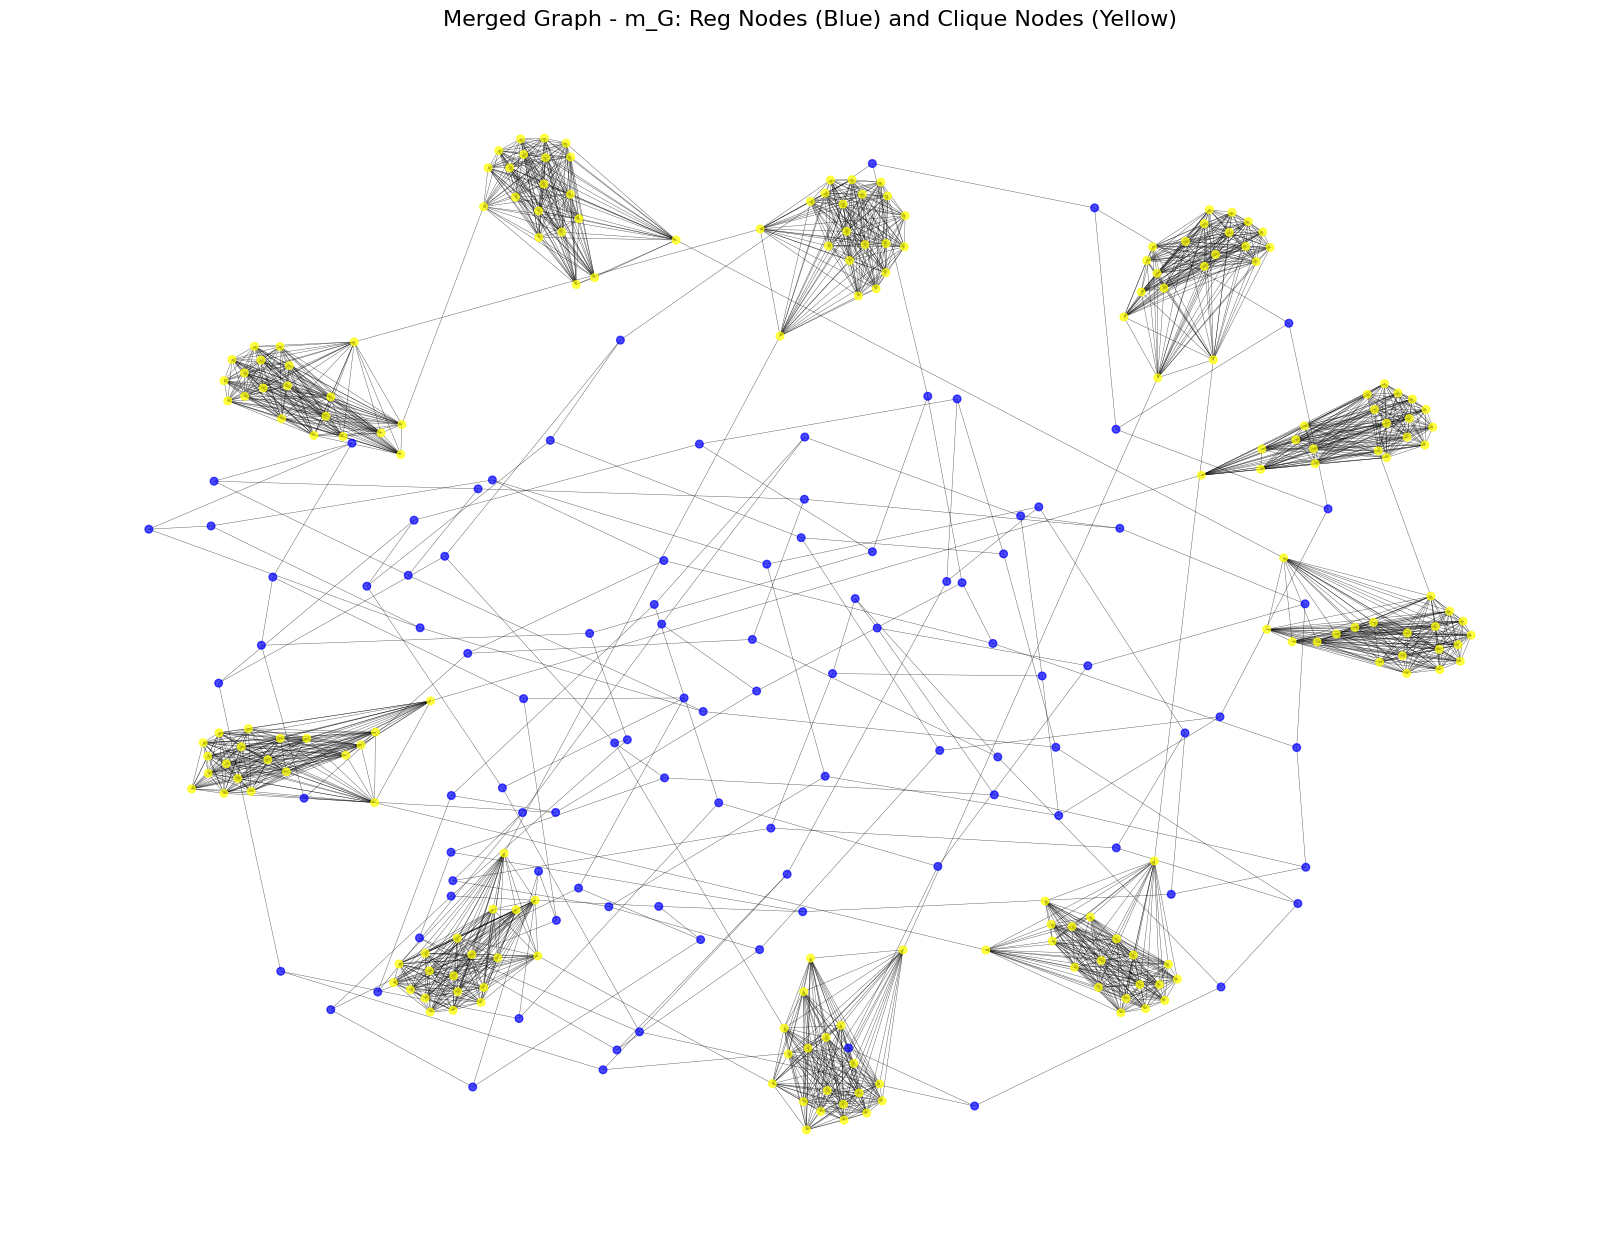

In [13]:
import matplotlib.pyplot as plt
import random

nodes = list(m_G.nodes())

reg_nodes = [n for n in nodes if n.startswith('reg_')]
cliq_nodes = [n for n in nodes if n.startswith('cliq_')]

while not nx.is_connected(m_G):
    node1 = random.choice(reg_nodes)
    node2 = random.choice(cliq_nodes)
    if not m_G.has_edge(node1, node2):
        m_G.add_edge(node1, node2)

node_colors = []
for node in m_G.nodes():
    if node.startswith('reg_'):
        node_colors.append('blue')
    else:
        node_colors.append('yellow')

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(m_G, k=0.3, iterations=50, seed=42)
nx.draw(m_G, pos, node_color=node_colors, node_size=30, 
        width=0.3, alpha=0.7, with_labels=False)
plt.title('Merged Graph - m_G: Reg Nodes (Blue) and Clique Nodes (Yellow)', fontsize=16)
plt.axis('off')
plt.show()

Use algorithm from Exercise 1

Sample node attributes: {'reg_0': {'Ni': 3, 'Ei': 3, 'Wi': 3, 'lambda_w_i': np.float64(1.7320508075688772), 'anomaly_score': np.float64(0.18293843624663367), 'combined_anomaly_score': np.float64(1.0)}, 'reg_1': {'Ni': 3, 'Ei': 3, 'Wi': 3, 'lambda_w_i': np.float64(1.7320508075688772), 'anomaly_score': np.float64(0.18293843624663367), 'combined_anomaly_score': np.float64(1.0)}, 'reg_2': {'Ni': 3, 'Ei': 3, 'Wi': 3, 'lambda_w_i': np.float64(1.7320508075688772), 'anomaly_score': np.float64(0.18293843624663367), 'combined_anomaly_score': np.float64(1.0)}}
Sample anomaly scores: {'reg_0': np.float64(0.18293843624663367), 'reg_1': np.float64(0.18293843624663367), 'reg_2': np.float64(0.18293843624663367)}
Top 10 nodes by combined anomaly score: ['cliq_0', 'cliq_20', 'cliq_40', 'cliq_60', 'cliq_80', 'cliq_100', 'cliq_120', 'cliq_140', 'cliq_160', 'cliq_180']


d:\FMI\Anomaly-Detection\AD\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


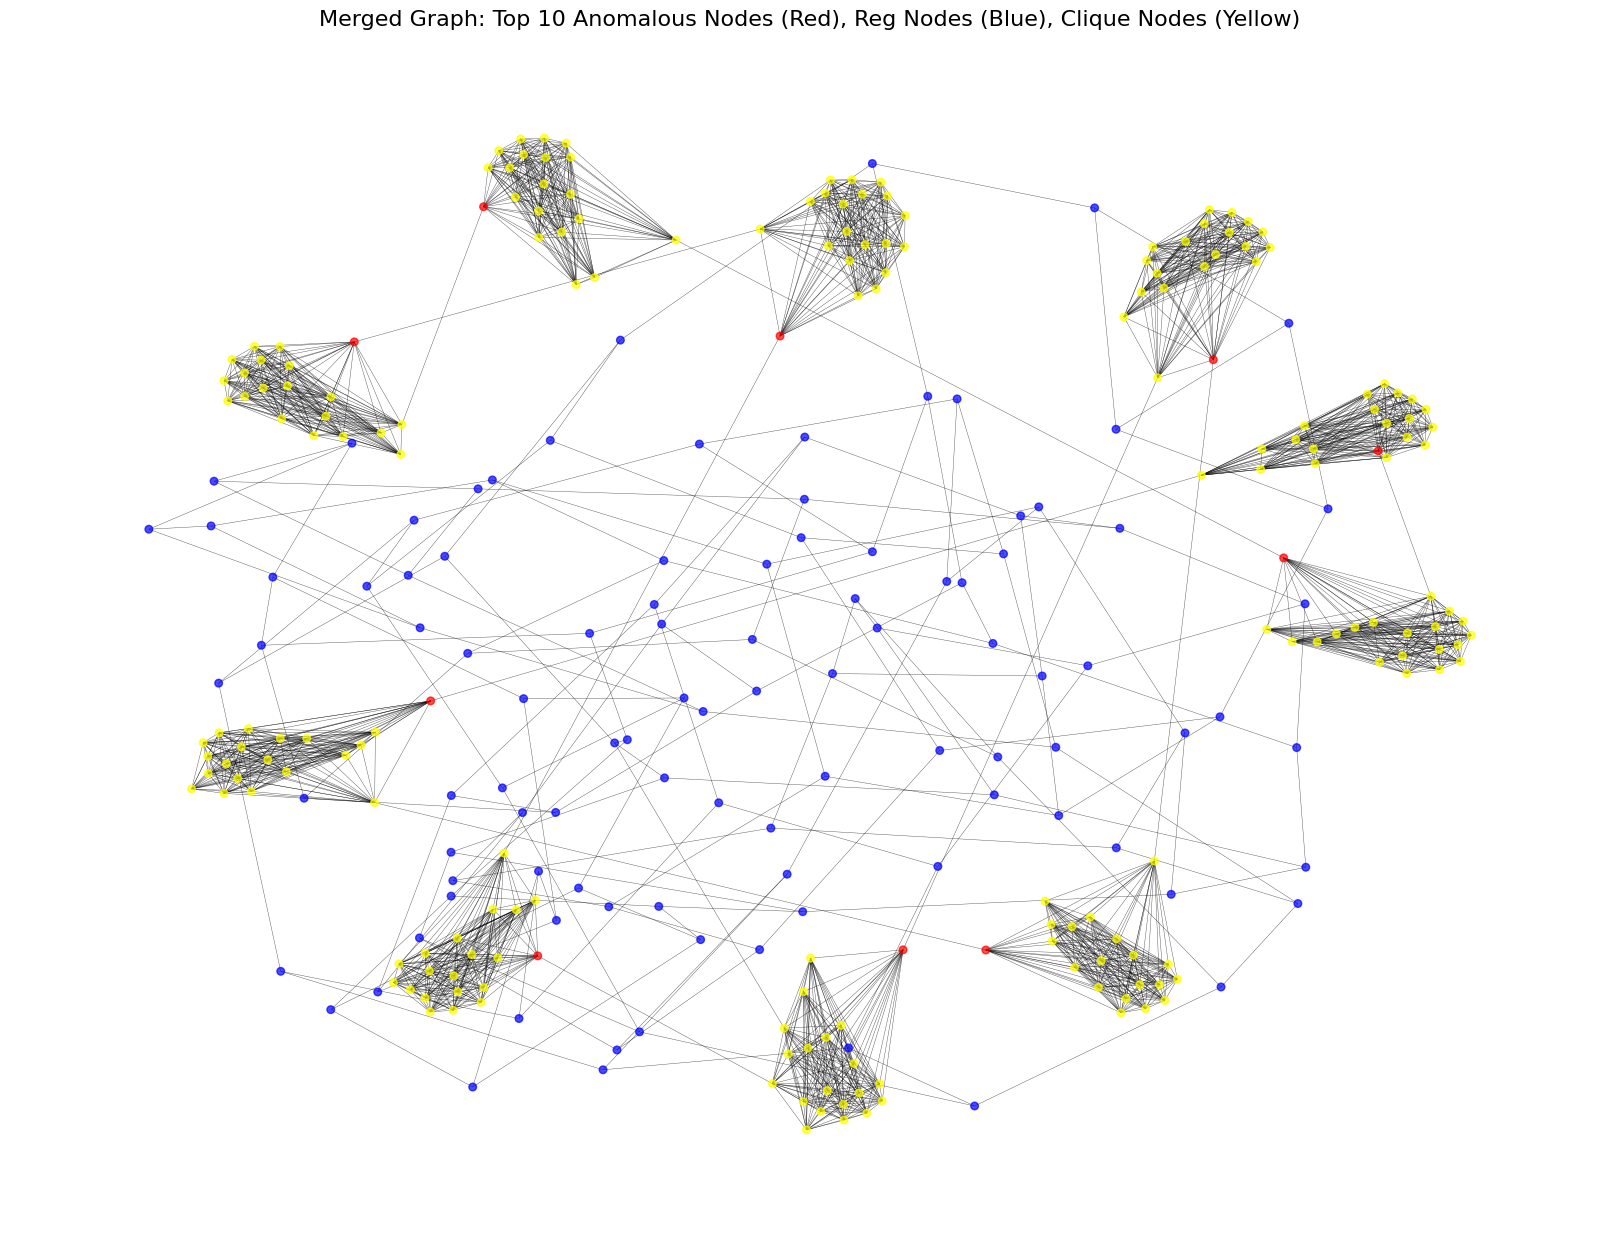

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Extract features from egonet for m_G
node_attributes = {}

for node in m_G.nodes():
    # number of neighbors
    Ni = len(list(m_G.neighbors(node)))
    
    # Egonet: subgraph induced by node and its neighbors
    egonet_nodes = list(m_G.neighbors(node)) + [node]
    egonet = m_G.subgraph(egonet_nodes)
    
    # number of edges in egonet
    Ei = egonet.number_of_edges()
    
    # total weight of egonet (assuming weight=1 for all edges)
    Wi = sum(1 for _ in egonet.edges())  # since no weights, just count edges
    
    # principal eigenvalue of adjacency matrix
    if egonet.number_of_nodes() > 0:
        adj_matrix = nx.adjacency_matrix(egonet).todense()
        eigenvalues = np.linalg.eigvals(adj_matrix)
        lambda_w_i = max(eigenvalues.real)
    else:
        lambda_w_i = 0
    
    node_attributes[node] = {
        'Ni': Ni,
        'Ei': Ei,
        'Wi': Wi,
        'lambda_w_i': lambda_w_i
    }

nx.set_node_attributes(m_G, node_attributes)

print("Sample node attributes:", dict(list(m_G.nodes(data=True))[:3]))

# Anomaly scores using regression


log_x = []
log_y = []

for node in m_G.nodes():
    Ni = m_G.nodes[node]['Ni']
    Ei = m_G.nodes[node]['Ei']
    if Ni > 0 and Ei > 0:
        log_x.append(np.log(Ni))
        log_y.append(np.log(Ei))

log_x = np.array(log_x).reshape(-1, 1)
log_y = np.array(log_y)

lin_reg = LinearRegression()
lin_reg.fit(log_x, log_y)

C = np.exp(lin_reg.intercept_)
theta = lin_reg.coef_[0]

anom_scores = {}
for node in m_G.nodes():
    score = 0
    Ni = m_G.nodes[node]['Ni']
    Ei = m_G.nodes[node]['Ei']
    if Ni > 0:
        Ei_pred = C * (Ni ** theta)
        diff = Ei - Ei_pred
        score = max(Ei, Ei_pred) - min(Ei, Ei_pred) + np.log(np.abs(diff) + 1)
    anom_scores[node] = score

nx.set_node_attributes(m_G, anom_scores, 'anomaly_score')

print("Sample anomaly scores:", {node: m_G.nodes[node]['anomaly_score'] for node in list(m_G.nodes())[:3]})

# LOF and combined scores


lof_data = []
node_list = list(m_G.nodes())
for node in node_list:
    Ni = m_G.nodes[node]['Ni']
    Ei = m_G.nodes[node]['Ei']
    lof_data.append([Ni, Ei])

lof_data = np.array(lof_data)
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
lof.fit_predict(lof_data)
lof_scores = -lof.negative_outlier_factor_

# Normalize original anomaly scores
original_scores = [m_G.nodes[node]['anomaly_score'] for node in node_list]
scaler = MinMaxScaler()
normalized_original = scaler.fit_transform(np.array(original_scores).reshape(-1, 1)).flatten()

combined_scores = normalized_original + lof_scores

combined_dict = {node: score for node, score in zip(node_list, combined_scores)}
nx.set_node_attributes(m_G, combined_dict, 'combined_anomaly_score')

sorted_nodes_combined = sorted(m_G.nodes(), key=lambda n: m_G.nodes[n]['combined_anomaly_score'], reverse=True)
print("Top 10 nodes by combined anomaly score:", sorted_nodes_combined[:10])

# Visualize with top 10 in red
top_10_combined = sorted_nodes_combined[:10]

node_colors_combined = []
for node in m_G.nodes():
    if node in top_10_combined:
        node_colors_combined.append('red')
    elif node.startswith('reg_'):
        node_colors_combined.append('blue')
    else:
        node_colors_combined.append('yellow')

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(m_G, k=0.3, iterations=50, seed=42)
nx.draw(m_G, pos, node_color=node_colors_combined, node_size=30, 
        width=0.3, alpha=0.7, with_labels=False)
plt.title('Merged Graph: Top 10 Anomalous Nodes (Red), Reg Nodes (Blue), Clique Nodes (Yellow)', fontsize=16)
plt.axis('off')
plt.show()

2 - HeavyVicinity anomalies

Top 4 nodes by LOF score (heavy vicinity anomalies): ['reg5_2', 'reg5_42', 'reg5_26', 'reg5_80']


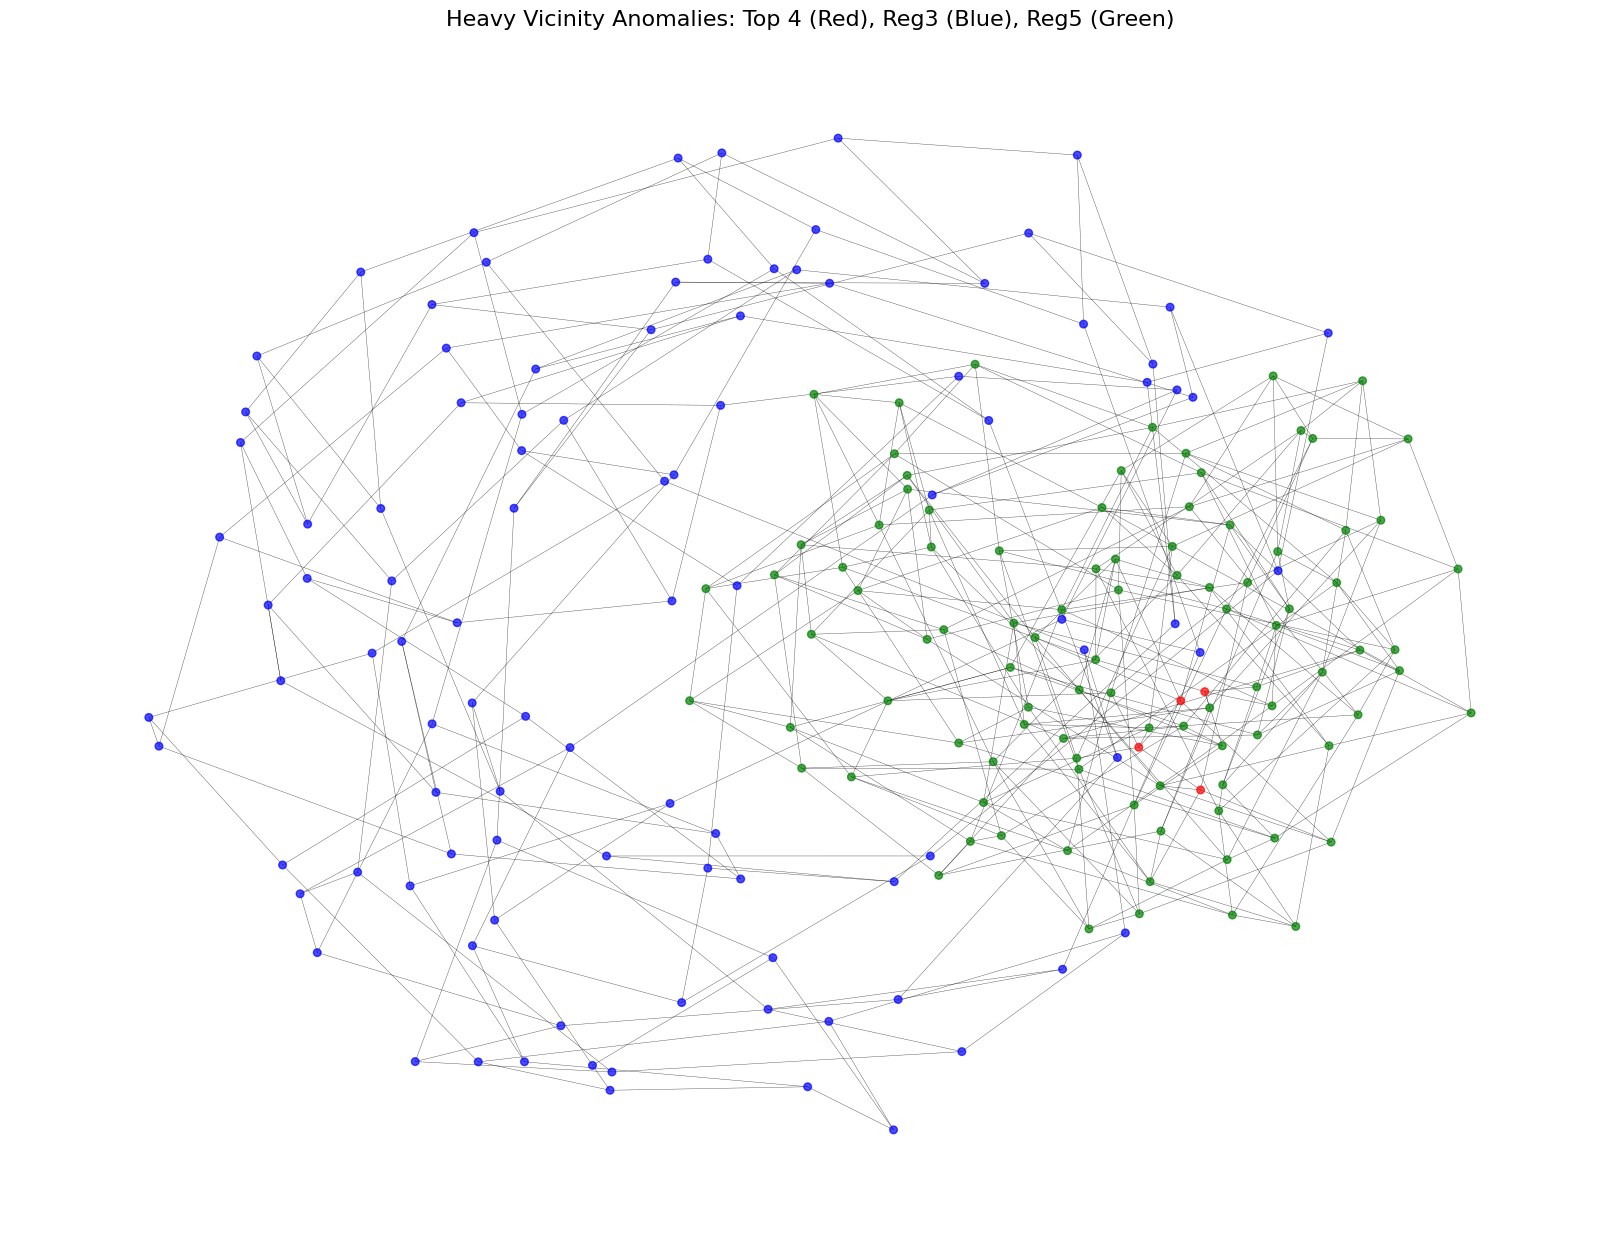

In [22]:
import random

# Generate graphs
reg3_G = nx.random_regular_graph(d=3, n=100)
reg5_G = nx.random_regular_graph(d=5, n=100)

# Merge
heavy_G = nx.union(reg3_G, reg5_G, rename=('reg3_', 'reg5_'))

# Assign weights
for edge in heavy_G.edges():
    heavy_G.add_edge(edge[0], edge[1], weight=1)

# Pick 2 random nodes and add 10 to egonet edges
all_nodes = list(heavy_G.nodes())
anomaly_nodes = random.sample(all_nodes, 2)

for node in anomaly_nodes:
    egonet_nodes = list(heavy_G.neighbors(node)) + [node]
    egonet = heavy_G.subgraph(egonet_nodes)
    for u, v in egonet.edges():
        heavy_G[u][v]['weight'] += 10

# Extract features (similar to before, but focus on Wi and Ei)
node_attributes = {}

for node in heavy_G.nodes():
    Ni = len(list(heavy_G.neighbors(node)))
    
    egonet_nodes = list(heavy_G.neighbors(node)) + [node]
    egonet = heavy_G.subgraph(egonet_nodes)
    
    Ei = egonet.number_of_edges()
    
    Wi = sum(heavy_G[u][v]['weight'] for u, v in egonet.edges())
    
    if egonet.number_of_nodes() > 0:
        adj_matrix = nx.adjacency_matrix(egonet, weight='weight').todense()
        eigenvalues = np.linalg.eigvals(adj_matrix)
        lambda_w_i = max(eigenvalues.real)
    else:
        lambda_w_i = 0
    
    node_attributes[node] = {
        'Ni': Ni,
        'Ei': Ei,
        'Wi': Wi,
        'lambda_w_i': lambda_w_i
    }

nx.set_node_attributes(heavy_G, node_attributes)

# Use LOF on Wi and Ei
lof_data = []
node_list = list(heavy_G.nodes())
for node in node_list:
    Wi = heavy_G.nodes[node]['Wi']
    Ei = heavy_G.nodes[node]['Ei']
    lof_data.append([Wi, Ei])

lof_data = np.array(lof_data)
lof = LocalOutlierFactor(n_neighbors = 70, contamination='auto')
lof.fit_predict(lof_data)
lof_scores = -lof.negative_outlier_factor_

# Set LOF scores
lof_dict = {node: score for node, score in zip(node_list, lof_scores)}
nx.set_node_attributes(heavy_G, lof_dict, 'lof_score')

sorted_nodes_lof = sorted(heavy_G.nodes(), key=lambda n: heavy_G.nodes[n]['lof_score'], reverse=True)
print("Top 4 nodes by LOF score (heavy vicinity anomalies):", sorted_nodes_lof[:4])

# Visualize
top_4 = sorted_nodes_lof[:4]

node_colors = []
for node in heavy_G.nodes():
    if node in top_4:
        node_colors.append('red')
    elif node.startswith('reg3_'):
        node_colors.append('blue')
    else:
        node_colors.append('green')

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(heavy_G, k=0.3, iterations=50, seed=42)
nx.draw(heavy_G, pos, node_color=node_colors, node_size=30, 
        width=0.3, alpha=0.7, with_labels=False)
plt.title('Heavy Vicinity Anomalies: Top 4 (Red), Reg3 (Blue), Reg5 (Green)', fontsize=16)
plt.axis('off')
plt.show()